In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
modes=['BandRemoval:4', 'BandRemoval:2', 'SuperFOV', 'SuperFOVi', 'SyntheticBanding']
model_dir = "D:/DeepSSFP/"
model_name="brain_phantom_dropout0_1"

Generating phantom...
Generating 3D phantom: (120, 434, 362)
Generating SSFP dataset...


c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:65: RuntimeWarning: divide by zero encountered in divide
  E1 = np.where(T1 > 0, np.exp(-TR / T1), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:66: RuntimeWarning: divide by zero encountered in divide
  E2 = np.where(T2 > 0, np.exp(-TR / T2), 0)
c:\Users\mmend\.conda\envs\mri\lib\site-packages\mssfp\simulations\ssfp.py:92: RuntimeWarning: divide by zero encountered in divide
  T2_decay = np.where(T2 > 0, np.exp(-TE / T2), 0)


Dataset complete.
Dataset shape: (120, 256, 256, 4)


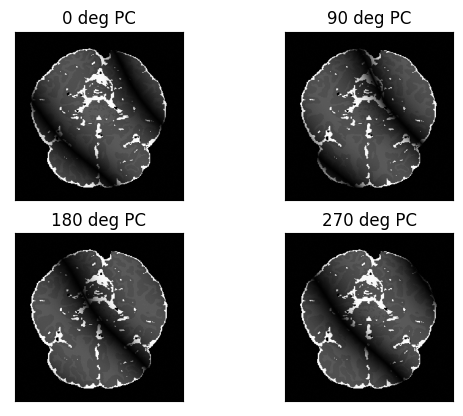

In [3]:
dataset = mssfp.generate_ssfp_dataset(
    phantom_type='brain', 
    npcs=4, 
    f=500, 
    alpha=np.deg2rad(60), 
    sigma=0.001, 
    data_indices=[(0, 2), (120,180)], 
    rotation=90,
    useRotate=True, 
    useDeform=True
)
mssfp.plot_dataset(dataset['M'], slice=0)


===== Running experiment: SuperFOVi =====
Model path: D:/DeepSSFP/brain_phantom_dropout0_1_superfovi
Dataset path: D:/DeepSSFP/brain_phantom_dropout0_1_dataset.npy
Saved dataset found. Loading from file: D:/DeepSSFP/brain_phantom_dropout0_1_dataset.npy
Data shape: (120, 256, 256, 4)
Training data shape: (96, 256, 256, 2), (96, 256, 256, 2)
Input scaler stats: mean=0.0145, std=0.0723
Output scaler stats: mean=0.0079, std=0.0550
Selected indices: [ 5 11 10]
Figure size: (4, 6)


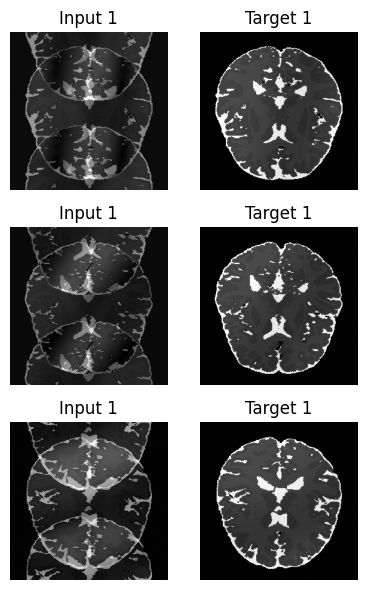

2025-03-26 17:01:41,121 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/brain_phantom_dropout0_1_superfovi
2025-03-26 17:01:41,122 - DeepSSFP - INFO - Training DataSet: (96, 256, 256, 2) | (96, 256, 256, 2)
2025-03-26 17:01:41,123 - DeepSSFP - INFO - Test DataSet: (24, 256, 256, 2) | (24, 256, 256, 2)



Training model...


2025-03-26 17:01:41,735 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/brain_phantom_dropout0_1_superfovi.keras
2025-03-26 17:01:43,122 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/brain_phantom_dropout0_1_superfovi_history.npz
2025-03-26 17:01:43,126 - DeepSSFP - INFO - Continuing training from epoch 0


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 256, 256, 2) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 256, 256, 32) 608         img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 256, 256, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 256, 256, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-03-26 17:19:22,981 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/brain_phantom_dropout0_1_superfovi.keras


1/1 [==============================] - 2s 2s/step - loss: 0.0238 - mean_absolute_error: 0.0599


2025-03-26 17:19:25,483 - DeepSSFP - INFO - Training Complete. Loss: 0.0238, MAE: 0.0599
2025-03-26 17:19:25,483 - DeepSSFP - INFO - Time Elapsed: 1062.35 seconds
2025-03-26 17:19:26,793 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/brain_phantom_dropout0_1_superfovi_training_history.png


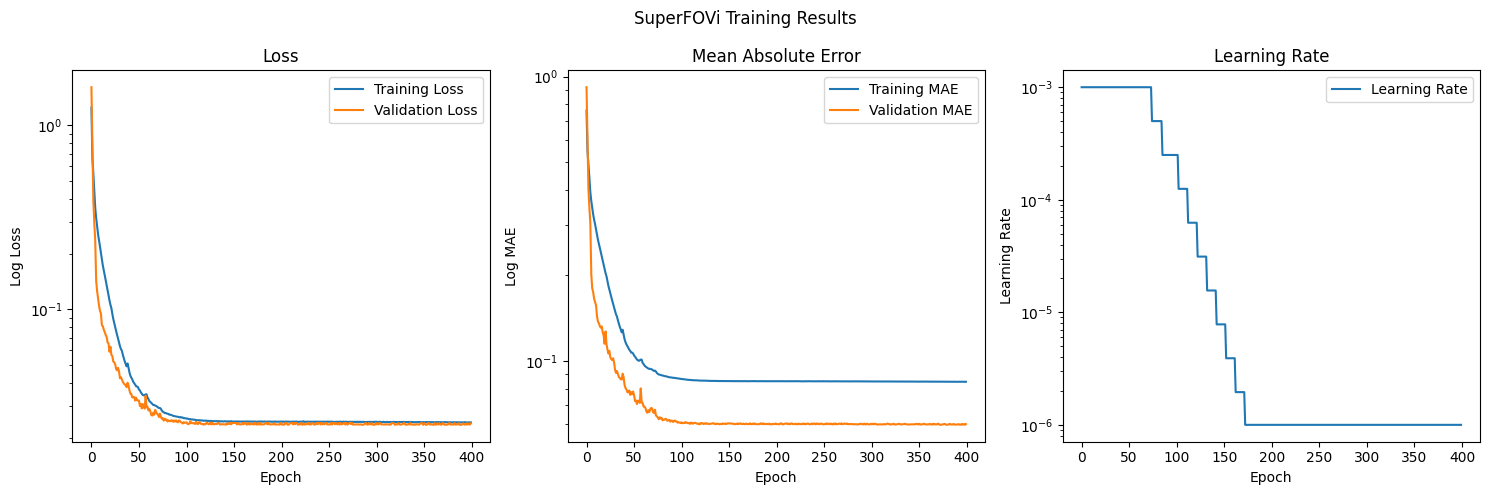

2025-03-26 17:19:54,161 - DeepSSFP - INFO - Making predictions on data with shape (24, 256, 256, 2)
2025-03-26 17:19:54,413 - DeepSSFP - INFO - Predictions complete. Output shape: (24, 256, 256, 2)


Selected indices: [14  8]
Figure size: (6, 4)
Image visualization saved to D:/DeepSSFP/brain_phantom_dropout0_1_superfovi_prediction_results.png


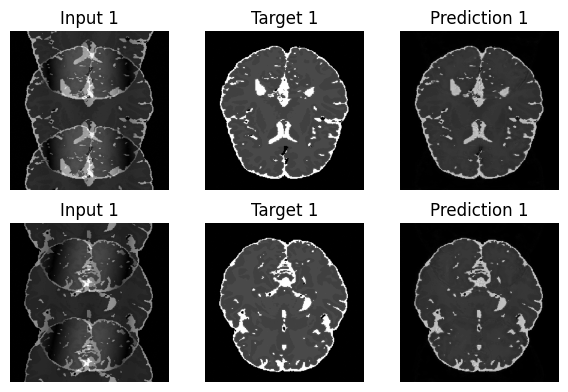

Target shape: (24, 256, 256), Prediction shape: (24, 256, 256)


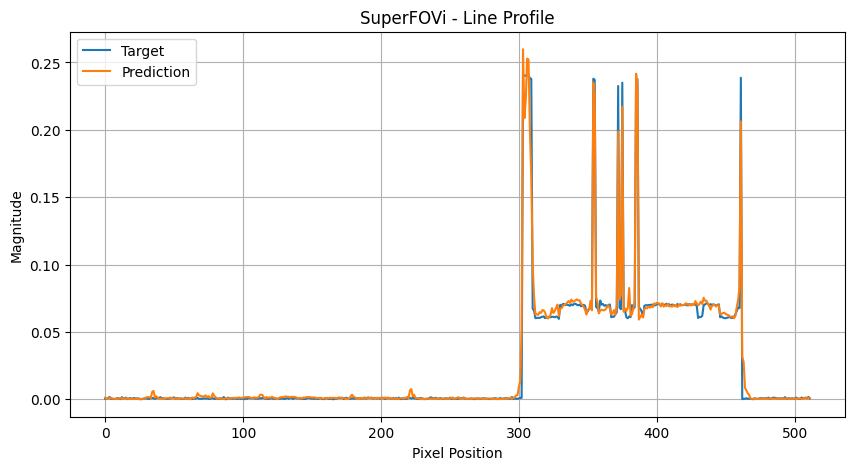


Evaluating band reduction...
Target shape: (24, 256, 256)
Prediction shape: (24, 256, 256)
Segmentation shape: (24, 256, 256)
Unique segmentation IDs: [0. 1. 2. 3.]
IDs to plot: [1. 2. 3.]
Training history plot saved to D:/DeepSSFP/brain_phantom_dropout0_1_superfovi_band_metrics_scatter


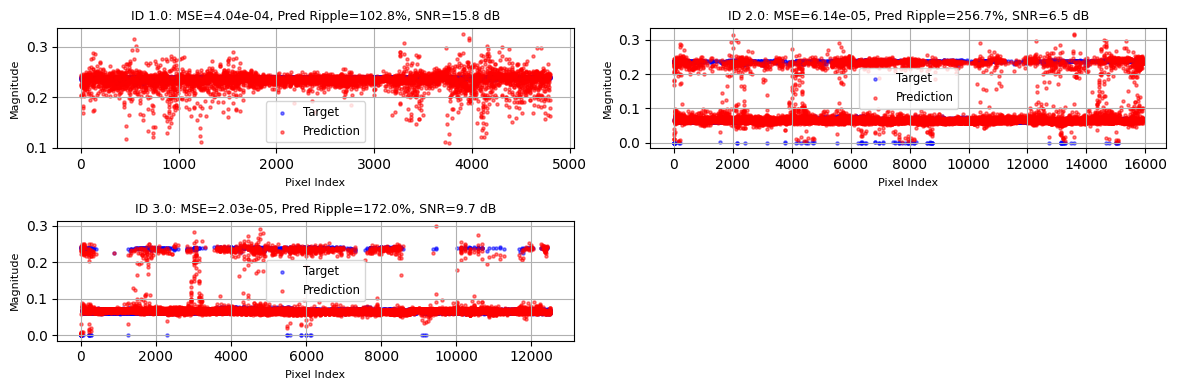

Training history plot saved to D:/DeepSSFP/brain_phantom_dropout0_1_superfovi_band_metrics


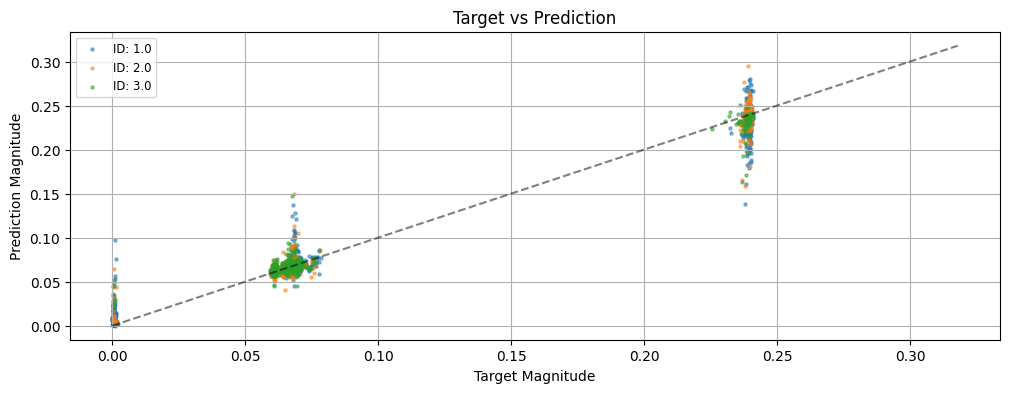


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=4.04e-04, MAE=1.23e-02, Pred Min=0.0921, Pred Max=0.3297, Pred Ripple=102.80%, Pred SNR=15.8 dB, Target Min=0.2218, Target Max=0.2417, Target Ripple=8.36%, Target SNR=15.8 dB, Samples=24, Pixels=4800
ID 2.0: MSE=6.14e-05, MAE=3.98e-03, Pred Min=0.0309, Pred Max=0.1960, Pred Ripple=256.73%, Pred SNR=6.5 dB, Target Min=0.0589, Target Max=0.0701, Target Ripple=17.82%, Target SNR=6.0 dB, Samples=24, Pixels=15919
ID 3.0: MSE=2.03e-05, MAE=2.79e-03, Pred Min=0.0448, Pred Max=0.1626, Pred Ripple=172.02%, Pred SNR=9.7 dB, Target Min=0.0680, Target Max=0.0790, Target Ripple=15.72%, Target SNR=9.7 dB, Samples=24, Pixels=12497

Calculating image quality metrics...

===== Image Quality Metrics =====

GLOBAL:
  MSE: 0.000058
  MAE: 0.003065
  PSNR: 42.838346
  SSIM: 0.986681
  NRMSE: 0.094455

SEGMENT_0.0:
  MSE: 0.000018
  MAE: 0.001298
  PSNR: 47.642465
  SSIM: nan
  NRMSE: 5.840699

SEGMENT_1.0:
  MSE: 0.000404
  MAE: 0.012254
  P

In [4]:
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SuperFOVi.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    custom_dataset=dataset
)

In [10]:
mode = deepssfp.DataMode.SuperFOV.value
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")

model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

print(history_dict['val_loss'])

2025-03-26 12:26:15,656 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/brain_phantom_dropout0_1_superfov
2025-03-26 12:26:16,232 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/brain_phantom_dropout0_1_superfov.keras
2025-03-26 12:26:16,233 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/brain_phantom_dropout0_1_superfov_history.npz


[0.6598544120788574, 0.30147871375083923, 0.23691272735595703, 0.21691064536571503, 0.20026759803295135, 0.18673379719257355, 0.18133732676506042, 0.17474429309368134, 0.17202816903591156, 0.16679558157920837, 0.16514381766319275, 0.1609804928302765, 0.15800704061985016, 0.1547607034444809, 0.15414829552173615, 0.15162290632724762, 0.14937050640583038, 0.1500461995601654, 0.14580971002578735, 0.1429327428340912, 0.14070925116539001, 0.13907086849212646, 0.1369553804397583, 0.13625633716583252, 0.13350065052509308, 0.13106349110603333, 0.12970201671123505, 0.12783214449882507, 0.1263299286365509, 0.12467461824417114, 0.12187820672988892, 0.12237153202295303, 0.11745820194482803, 0.11837776005268097, 0.11614608764648438, 0.11447908729314804, 0.11290005594491959, 0.11187927424907684, 0.11055237054824829, 0.11054481565952301, 0.10751904547214508, 0.1064726710319519, 0.10478568077087402, 0.10452502965927124, 0.10386104881763458, 0.10309650748968124, 0.10356290638446808, 0.1007508859038353, 

In [ ]:
deepssfp.analysis.run_all_experiments(
    modes=modes,
    model_name=model_name,
    model_dir=model_dir,
    train_models=True,  # Set to False to use pre-trained models
    custom_dataset=dataset
)

In [ ]:
# Compare experiment results
deepssfp.analysis.compare_experiments(
    modes=modes,
    model_name=model_name,
    model_dir=model_dir
)